In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("3-customersatisfaction.csv")

In [4]:
df.head()

,Unnamed: 0,Customer Satisfaction,Incentive
0,0,-1.282447,1.010513
1,1,0.425298,2.281043
2,2,1.953070,4.415053
3,3,2.625838,10.563600
4,4,-1.426333,0.627365


In [5]:
df.drop(columns="Unnamed: 0",axis=1,inplace=True)

In [6]:
df

,Customer Satisfaction,Incentive
0,-1.282447,1.010513
1,0.425298,2.281043
2,1.953070,4.415053
3,2.625838,10.563600
4,-1.426333,0.627365
...,...,...
95,2.055072,8.686851
96,0.864149,2.901486
97,-1.586101,0.786207
98,1.558528,5.447475


In [7]:
X = df[["Customer Satisfaction"]]
y = df["Incentive"]

In [34]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=15)

In [35]:
scaler  = StandardScaler()

In [36]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [37]:
regression = LinearRegression()

In [38]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [39]:
y_pred = regression.predict(X_test)

In [40]:
print("R2 Score : ",r2_score(y_test,y_pred))

R2 Score :  0.2705652535622244


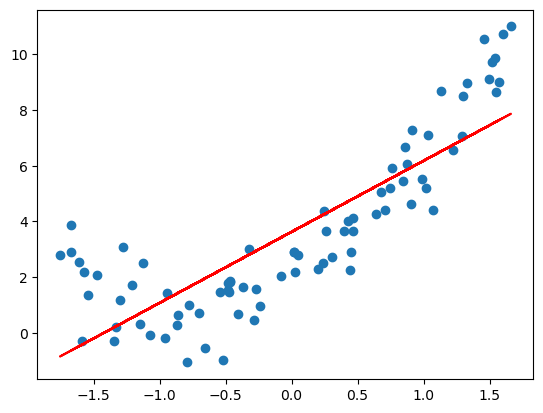

In [41]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color = "r")
plt.show()

In [92]:
poly = PolynomialFeatures(degree = 2,include_bias=True)

In [93]:
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [94]:
regression.fit(X_train_poly,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [95]:
y_pred_poly = regression.predict(X_test_poly)

In [96]:
print("R2 Score : ",r2_score(y_test,y_pred_poly))

R2 Score :  0.7685687698788557


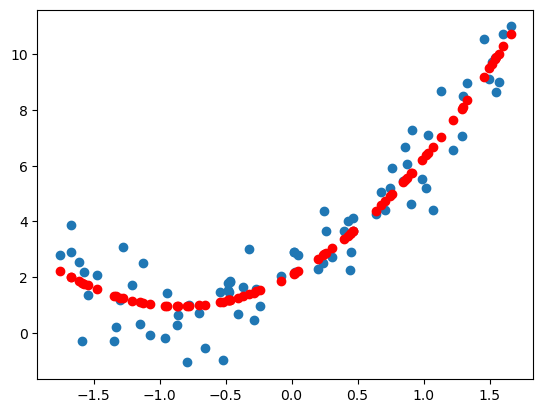

In [97]:
plt.scatter(X_train,y_train)
plt.scatter(X_train,regression.predict(X_train_poly),color = "r")
plt.show()